# 06 · A model artifact another process can load

Train a public EuroSAT forest, log it locally with MLflow, include its feature schema and environment, and reproduce predictions in a fresh Python process.

[Notebook index](README.md) · [Companion article](../docs/articles/model-artifacts-mlflow.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
from geoai_portfolio.artifacts import log_forest, predict_table, reload_in_fresh_process
from geoai_portfolio.experiments import EuroSAT, fit_forest, scores
from geoai_portfolio.io import sha256

data = ensure_data("eurosat")
out = workspace("06-artifacts")
dataset = EuroSAT.load(data)
features = dataset.features(dataset.bands)
train, test = dataset.mask("train"), dataset.mask("test")
model = fit_forest(dataset, features)
display(
    pd.DataFrame(
        {
            "partition": ["train", "test"],
            "chips": [train.sum(), test.sum()],
            "features": [features.shape[1], features.shape[1]],
        }
    )
)

,partition,chips,features
0,train,2000,65
1,test,499,65


## Package the prediction contract

The saved scikit-learn pipeline includes training-fitted preprocessing. MLflow stores
a signature, an input example, and pinned Python requirements. A separate JSON schema
records column names and order, units, band definitions and dataset identity. The local
SQLite tracking store and artifact directory require no remote service or credentials.
Load only model packages you trust: the scikit-learn flavor uses Python serialization.

In [3]:
package = log_forest(
    model,
    features.loc[train],
    dataset.samples.loc[train, "label"],
    out,
    {
        "bands": dataset.bands,
        "data_version": "public-data-v1",
        "samples_sha256": sha256(data / "samples.csv"),
        "seed": 42,
    },
)
files = pd.DataFrame(
    [
        {"file": p.relative_to(package).as_posix(), "bytes": p.stat().st_size}
        for p in sorted(package.rglob("*"))
        if p.is_file()
    ]
)
display(files)
schema = json.loads((package / "feature_schema.json").read_text())
display(
    pd.DataFrame(
        {
            "feature": schema["columns"][:10],
            "dtype": [schema["dtypes"][c] for c in schema["columns"][:10]],
        }
    )
)

<checkout>\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/13 14:38:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/13 14:38:12 INFO mlflow.store.db.utils: Updating database tables


2026/09/13 14:38:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


,file,bytes
0,conda.yaml,198
1,feature_schema.json,3262
2,input_example.json,7540
3,MLmodel,4831
4,model.skops,12486065
5,python_env.yaml,114
6,requirements.txt,80
7,serving_input_example.json,11056


,feature,dtype
0,B01_mean,float64
1,B02_mean,float64
2,B03_mean,float64
3,B04_mean,float64
4,B05_mean,float64
5,B06_mean,float64
6,B07_mean,float64
7,B08_mean,float64
8,B09_mean,float64
9,B10_mean,float64


## Reload outside the checkout

A subprocess starts with Python's isolated flag and a temporary working directory. It
imports MLflow and pandas directly, reads the saved CSV, and loads the model without
importing this repository. This verifies artifact independence from notebook state.
The next notebook also verifies installation in a separate environment.

In [4]:
example = features.loc[test].iloc[:40]
expected = model.predict(example)
local = predict_table(package, example)
external = reload_in_fresh_process(package, example)
np.testing.assert_array_equal(expected, local)
np.testing.assert_array_equal(expected, external)
display(pd.DataFrame({"original": expected, "loaded": local, "fresh_process": external}).head(12))
try:
    predict_table(package, example[example.columns[::-1]])
except ValueError as error:
    print("Expected schema rejection:", error)
else:
    raise AssertionError("Reordered features were accepted")

,original,loaded,fresh_process
0,3,3,3
1,6,6,6
2,3,3,3
3,2,2,2
4,3,3,3
5,6,6,6
6,7,7,7
7,2,2,2
8,4,4,4
9,2,2,2


Expected schema rejection: Feature names and order must match the saved schema


,accuracy,macro_f1
0,0.6593,0.6481


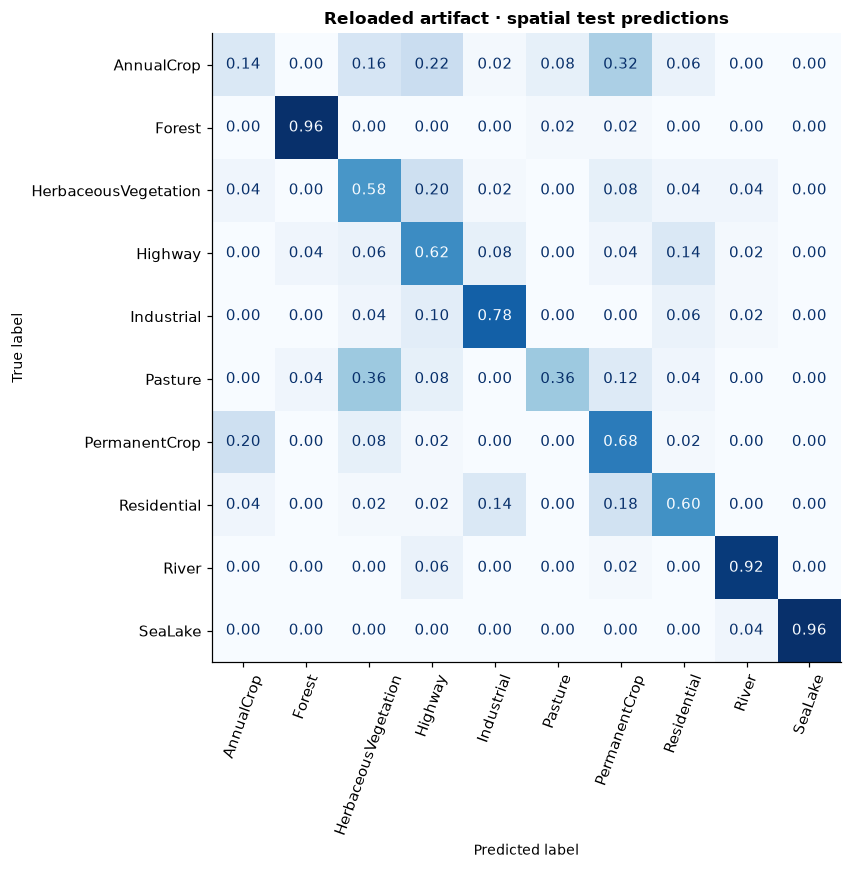

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

held_out = features.loc[test]
predicted = predict_table(package, held_out)
display(pd.DataFrame([scores(dataset.samples.loc[test, "label"], predicted)]))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    dataset.samples.loc[test, "label"],
    predicted,
    display_labels=dataset.classes,
    normalize="true",
    xticks_rotation=70,
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
)
ax.set_title("Reloaded artifact · spatial test predictions")
plt.tight_layout()
plt.show()

## What travels with the artifact

Correct weights with the wrong feature order can produce plausible but wrong results.
The explicit schema prevents that failure at the application boundary. Artifact reload
does not prove robustness to arbitrary dependency changes; it reproduces predictions in
the declared environment. Run IDs and serialization bytes may vary between executions.
Public subset scores describe this experiment only.

[MLflow model signatures](https://mlflow.org/docs/latest/ml/model/signatures/)
document model input and output contracts.